# 04 - Two-Way Fixed Effects DiD

State + year FE removes time-invariant state characteristics and common year effects. This is the standard DiD estimator but is biased under staggered adoption with heterogeneous effects. Notebook 05 corrects this.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

FARS_FILE = "fars_state_year.parquet"
CDC_FILE  = "cdc_state_year.parquet"

# Load FARS panel
if not (DATA_DIR / FARS_FILE).exists():
    raise FileNotFoundError(
        f"{FARS_FILE} not found. Run:\n"
        "  python scripts/download_fars.py\n"
        "  python src/build_fars_panel.py"
    )
fars = pd.read_parquet(DATA_DIR / FARS_FILE)
leg  = pd.read_csv("../data/codebooks/state_legalization_dates.csv")
print(f"FARS panel: {fars.shape}  |  States: {fars['state'].nunique()}  |  Years: {sorted(fars['year'].dropna().unique()[:3])}...{sorted(fars['year'].dropna().unique()[-3:])}")

FARS panel: (676, 11)  |  States: 51  |  Years: [np.int64(2010), np.int64(2011), np.int64(2012)]...[np.int64(2020), np.int64(2021), np.int64(2022)]


In [2]:
from linearmodels.panel import PanelOLS

In [3]:
primary = "total_fatalities_per_100k" if "total_fatalities_per_100k" in fars.columns else "total_fatalities"

# drop col if already present to avoid _x/_y suffix from merge
_leg_merge = leg[['state','retail_sales_year']]
fars_reg = fars.drop(columns=[c for c in ['retail_sales_year'] if c in fars.columns]).merge(_leg_merge, on='state', how='left')
fars_reg['post'] = (
    fars_reg['retail_sales_year'].notna() &
    (fars_reg['year'] >= fars_reg['retail_sales_year'])
).astype(float)

# Exclude states with legalization outside 2010-2022 window
in_window = leg[leg['retail_sales_year'].between(2010,2022)]['state'].tolist()
never = leg[leg['retail_sales_year'].isna()]['state'].tolist()
fars_twfe = fars_reg[fars_reg['state'].isin(in_window + never)].copy()

print(f"TWFE sample: {fars_twfe['state'].nunique()} states")
print(f"  Treated: {len(in_window)}, Never-treated: {len(never)}")

TWFE sample: 45 states
  Treated: 18, Never-treated: 29


## TWFE specification

In [4]:
twfe_idx = fars_twfe.set_index(['state','year'])
fe = PanelOLS(
    twfe_idx[primary],
    twfe_idx[['post']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='clustered', cluster_entity=True)

att = fe.params['post']
ci  = fe.conf_int().loc['post']
print(f"TWFE ATT (pooled): {att:.4f}  95% CI [{ci['lower']:.4f}, {ci['upper']:.4f}]")
print(f"Interpretation: {att:.4f} change in {primary.replace('_',' ')} per 100k after legalization")
print()
print(fe.summary.tables[1])

TWFE ATT (pooled): 0.7942  95% CI [0.1627, 1.4257]
Interpretation: 0.7942 change in total fatalities per 100k per 100k after legalization

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
post           0.7942     0.3215     2.4703     0.0138      0.1627      1.4257


## Why TWFE is biased here

With 15+ treatment cohorts from 2014-2022, TWFE uses **already-treated states as implicit controls** for later-treated states. If early adopters (CO, WA) had decreasing effects over time, TWFE can produce coefficients with the wrong sign even when the true effect is always negative.

Callaway-Sant'Anna (notebook 05) fixes this by restricting each cohort's comparison group to never-treated or not-yet-treated states.

In [5]:
# Visualize: do effects look like they differ by legalization year?
from linearmodels.panel import PanelOLS

cohort_results = {}
for yr in sorted(leg['retail_sales_year'].dropna().unique()):
    yr = int(yr)
    if yr > 2022: continue
    cohort_states = leg[leg['retail_sales_year']==yr]['state'].tolist()
    sub = fars_reg[fars_reg['state'].isin(cohort_states + never)].copy()
    sub['post_cohort'] = (sub['state'].isin(cohort_states) & (sub['year'] >= yr)).astype(float)
    try:
        idx = sub.set_index(['state','year'])
        fe_c = PanelOLS(idx[primary], idx[['post_cohort']],
                        entity_effects=True, time_effects=True).fit(
                        cov_type='clustered', cluster_entity=True)
        cohort_results[yr] = fe_c.params['post_cohort']
    except Exception:
        pass

print("Cohort-specific TWFE estimates (preliminary — C-S in next notebook):")
for yr, b in sorted(cohort_results.items()):
    print(f"  {yr} cohort: {b:+.4f}")
print("\nVariation across cohorts = evidence of heterogeneous effects = TWFE bias.")

Cohort-specific TWFE estimates (preliminary — C-S in next notebook):
  2014 cohort: +1.0725
  2015 cohort: +2.6526
  2016 cohort: +0.5968
  2017 cohort: +0.5773
  2018 cohort: +0.4265
  2019 cohort: +0.4155
  2020 cohort: +0.2798
  2021 cohort: +2.7270
  2022 cohort: -0.3611

Variation across cohorts = evidence of heterogeneous effects = TWFE bias.


## Cohort-specific effects — the TWFE warning sign

If the per-cohort effects vary a lot, the single pooled TWFE coefficient is an unreliable weighted average of them (Goodman-Bacon 2021). Plotting them motivates the Callaway–Sant'Anna estimator in notebook 05.

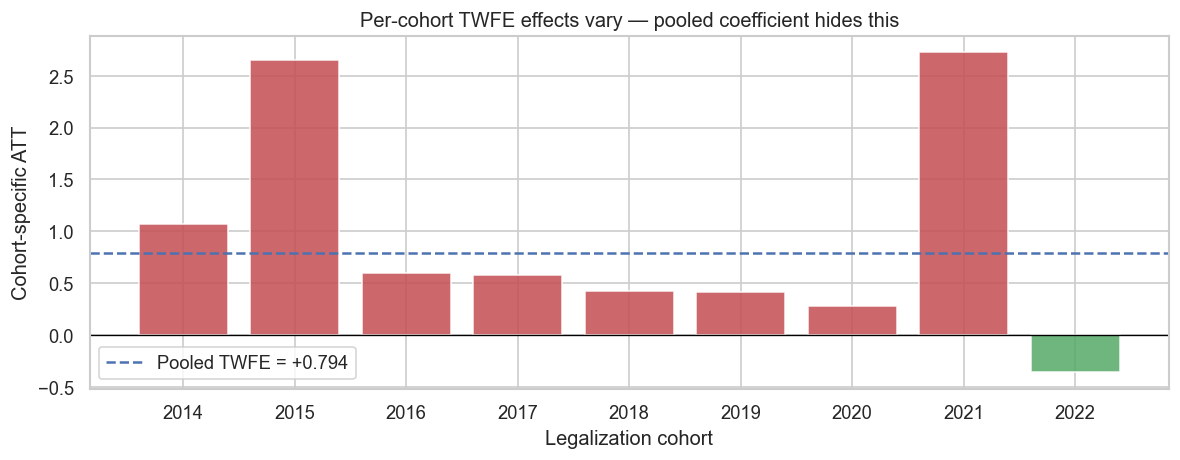

In [6]:
cr = pd.Series(cohort_results).sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#C44E52" if v>0 else "#55A868" for v in cr.values]
ax.bar(cr.index.astype(int).astype(str), cr.values, color=colors, alpha=0.85)
ax.axhline(att, color="#4C72B0", ls="--", lw=1.5, label=f"Pooled TWFE = {att:+.3f}")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Legalization cohort"); ax.set_ylabel("Cohort-specific ATT")
ax.set_title("Per-cohort TWFE effects vary — pooled coefficient hides this")
ax.legend(); plt.tight_layout(); plt.savefig(OUT_DIR/"04_cohort_effects.png", bbox_inches="tight"); plt.show()

**Takeaway.** The cohort effects scatter on both sides of the pooled estimate. Standard TWFE collapses them into one number using weights that can be negative for some 2×2 comparisons — exactly the failure mode Callaway–Sant'Anna avoids. Notebook 05 re-estimates this with clean cohort-vs-never-treated comparisons.